In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv("../day_28/train.csv",usecols=['Age','Fare','Survived'])
df.head(10)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
5,0,NaN,8.4583
6,0,54.0,51.8625
7,0,2.0,21.0750
8,1,27.0,11.1333
9,1,14.0,30.0708


In [4]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [5]:
df['Age'].fillna(df['Age'].mean(),inplace=True)
df.head()

C:\Users\mahad\AppData\Local\Temp\ipykernel_19260\3419160234.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['Survived']),df['Survived'],test_size=0.2,random_state=42)
x_train

,Age,Fare
331,45.500000,28.5000
733,23.000000,13.0000
382,32.000000,7.9250
704,26.000000,7.8542
813,6.000000,31.2750
...,...,...
106,21.000000,7.6500
270,29.699118,31.0000
860,41.000000,14.1083
435,14.000000,120.0000


C:\Users\mahad\AppData\Local\Temp\ipykernel_19260\4108148388.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'])


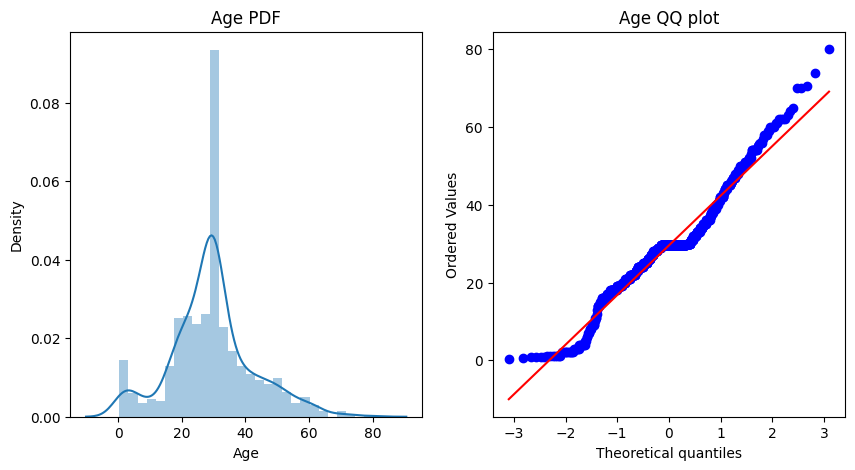

In [7]:
plt.figure(figsize=(10,5))
plt.subplot(121)
sns.distplot(x_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(x_train['Age'],dist='norm',plot=plt)
plt.title('Age QQ plot')

plt.show()

C:\Users\mahad\AppData\Local\Temp\ipykernel_19260\1262066841.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Fare'])


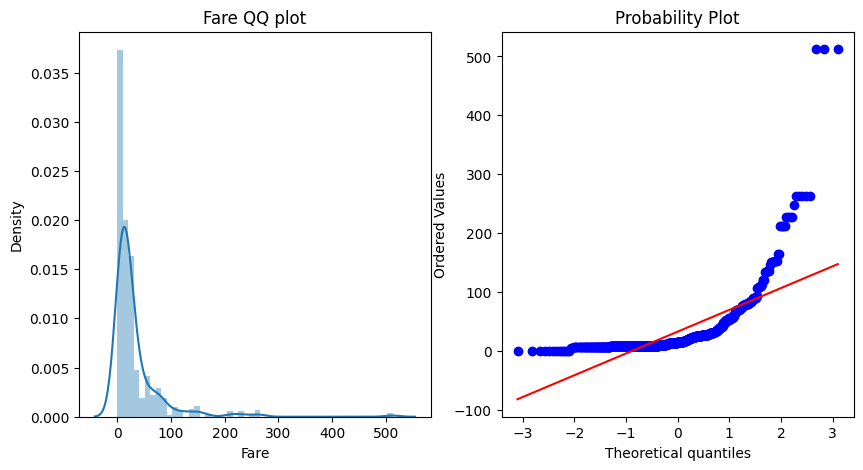

In [12]:
plt.figure(figsize=(10,5))
plt.subplot(121)
sns.distplot(x_train['Fare'])
plt.title('Fare PDF')
plt.title('Fare QQ plot')
plt.subplot(122)
stats.probplot(x_train['Fare'],dist='norm',plot=plt)
plt.show()

In [14]:
lr=LogisticRegression()
dt=DecisionTreeClassifier()

lr.fit(x_train,y_train)
dt.fit(x_train,y_train)
pred1=lr.predict(x_test)
pred2=dt.predict(x_test)

print('accuracy score of lr:',accuracy_score(y_test,pred1))
print('accuracy score of dt:',accuracy_score(y_test,pred2))

accuracy score of lr: 0.6480446927374302
accuracy score of dt: 0.659217877094972


In [15]:
func=FunctionTransformer(func=np.log1p)

x_train_trans=func.fit_transform(x_train)
x_test_trans=func.transform(x_test)

lr2=LogisticRegression()
dt2=DecisionTreeClassifier()

lr2.fit(x_train_trans,y_train)
dt2.fit(x_train_trans,y_train)
pred11=lr.predict(x_test_trans)
pred22=dt.predict(x_test_trans)

print('accuracy score of lr:',accuracy_score(y_test,pred11))
print('accuracy score of dt:',accuracy_score(y_test,pred22))

accuracy score of lr: 0.5865921787709497
accuracy score of dt: 0.4134078212290503


In [16]:
x_transform=func.fit_transform(df.drop(columns=['Survived']))


In [20]:
lr3=LogisticRegression()
dt3=DecisionTreeClassifier()

print('lr3',np.mean(cross_val_score(lr3,x_transform,df['Survived'],scoring='accuracy',cv=10)))
print('dt3',np.mean(cross_val_score(dt3,x_transform,df['Survived'],scoring='accuracy',cv=10)))

lr3 0.678027465667915
dt3 0.6566292134831462


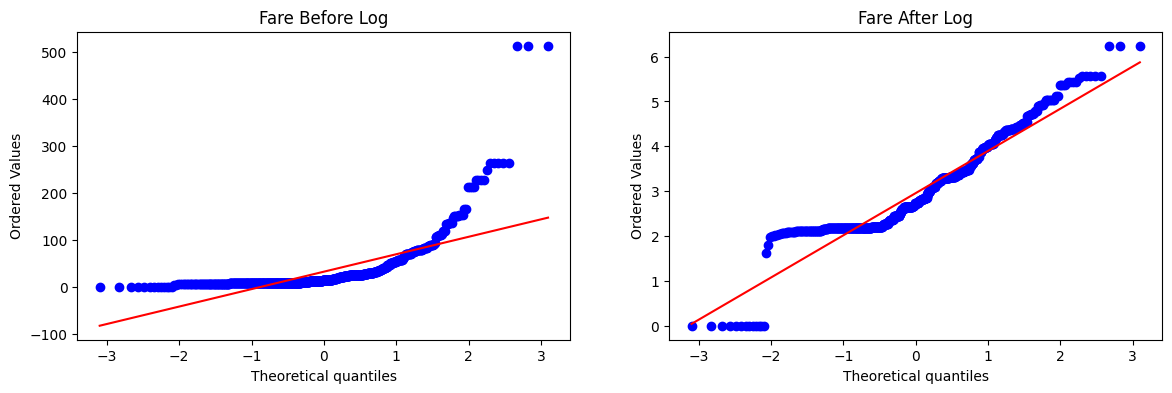

In [21]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train['Fare'], dist="norm", plot=plt)
plt.title('Fare Before Log')

plt.subplot(122)
stats.probplot(x_train_trans['Fare'], dist="norm", plot=plt)
plt.title('Fare After Log')

plt.show()


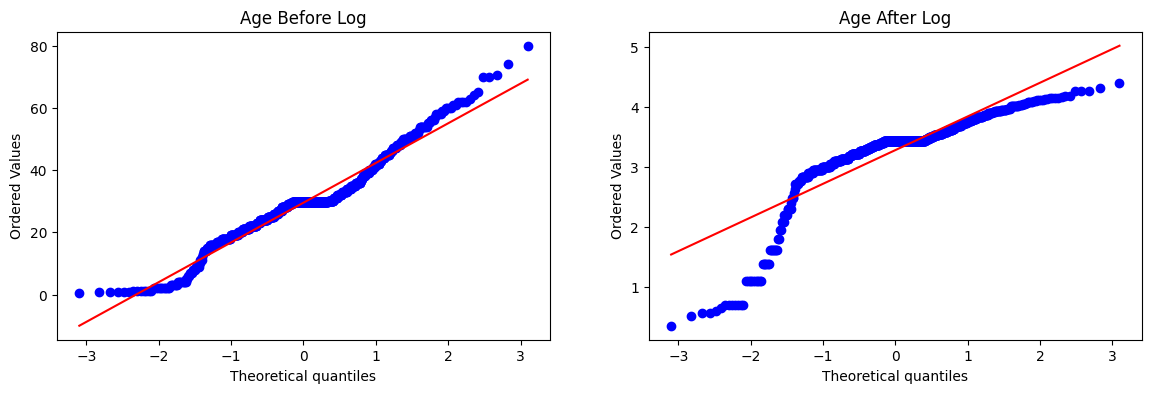

In [22]:
plt.figure(figsize=(14,4))

plt.subplot(121)
stats.probplot(x_train['Age'], dist="norm", plot=plt)
plt.title('Age Before Log')

plt.subplot(122)
stats.probplot(x_train_trans['Age'], dist="norm", plot=plt)
plt.title('Age After Log')

plt.show()

In [27]:
cltf=ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')
x_train_trans2=cltf.fit_transform(x_train)
x_test_trans2=cltf.transform(x_test)

In [29]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(x_train_trans,y_train)
clf2.fit(x_train_trans,y_train)
    
y_pred = clf.predict(x_test_trans)
y_pred2 = clf2.predict(x_test_trans)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6759776536312849


In [30]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()
    

Accuracy 0.6150561797752809


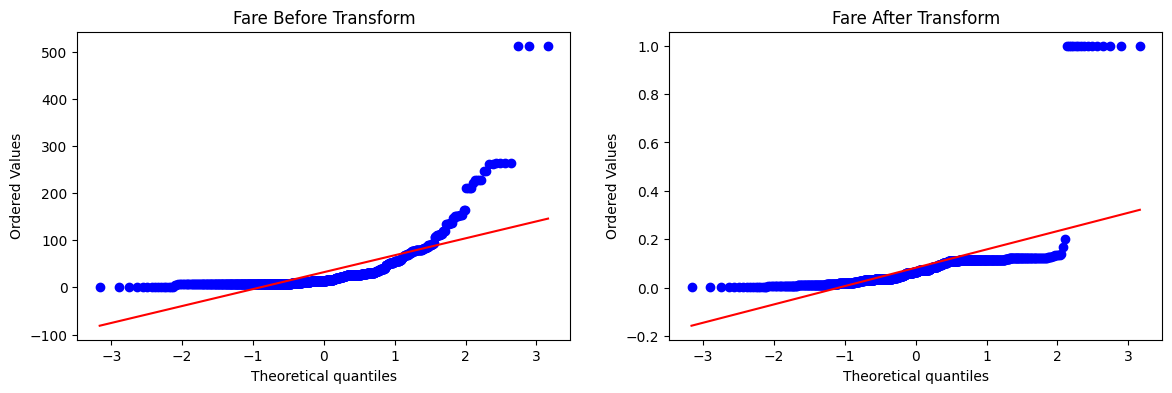

In [36]:
apply_transform(lambda x:1/(x+1))